## Corporate Bullshit Detector (featuring Jev)

The **Corporate Bullshit Detector** is a small experimental AI/ML project for analyzing **English-language corporate and professional social-media communication, especially LinkedIn posts**.

Its primary goal is to estimate how strongly a piece of corporate or professional communication exhibits characteristics commonly associated with corporate bullshit. Typical inputs include company posts, founder or executive posts, startup announcements, product launches, consulting thought leadership, AI hype, and other professional social-media content.

The detector does not claim to determine with absolute certainty whether a post is "bullshit" or "real". Instead, it evaluates several observable linguistic characteristics and expresses them as probabilities.

The system produces **probabilistic scores across separate dimensions** rather than asking a single model whether a text is "bullshit". A final overall Corporate Bullshit Score can later be derived deterministically from these individual signals.

Press releases and other corporate communication may still be used as secondary comparison examples, but professional social-media communication is the project's primary target domain.


### Core Decision Questions

## Core Decision Questions

| # | Dimension | Question | Output |
|---|---|---|---|
| 1 | Buzzword Saturation | How likely is it that this text relies heavily on trendy business, technology, startup, or marketing buzzwords rather than using them only where necessary? | `P(buzzword_saturation)` |
| 2 | Vagueness & Corporate Clichés | How likely is it that this text uses vague, generic, or formulaic corporate language while providing little clarity about what is actually being done, offered, changed, or achieved? | `P(vagueness)` |
| 3 | Grandiosity & Implausible Claims | How likely is it that this text makes exaggerated, grandiose, or implausible claims about its importance, novelty, capabilities, impact, or future consequences? | `P(grandiosity)` |
| 4 | Concrete Information | How likely is it that this text contains specific, concrete information about what happened, what was built, how something works, or what measurable result was achieved? | `P(concrete_information)` |


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
from pathlib import Path
from abc import ABC, abstractmethod
from dataclasses import dataclass

from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel, Field
from typesafe_sdk import Noul, TypeSafeClient

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, f1_score, precision_score, recall_score

load_dotenv("../../../corporate_bullshit.env")

True

## Datasets

The project uses two related datasets.



### Raw Dataset

`corporate_bullshit_raw_dataset.csv`

The raw dataset contains a broader collection of synthetic and authentic corporate or professional communication, with a strong focus on LinkedIn-style posts. It serves as the general pool of examples used for experimentation and later model evaluation.

| Column | Description |
|---|---|
| `id` | Unique sample identifier |
| `synthetic_or_real` | Indicates whether the sample is synthetic or based on authentic public communication |
| `text` | The corporate or professional communication to be analyzed |
| `source_type` | Type of communication, such as LinkedIn post, press release, or corporate update |
| `domain` | Industry or subject domain |
| `archetype` | Descriptive construction category used when assembling the dataset; not a ground-truth label |

### Golden Set

`corporate_bullshit_golden_set.csv`

The golden set is a manually reviewed subset of the raw dataset. Each sample was labeled according to the four dimensions used by the detector and acts as the human reference for evaluation.

| Column | Description |
|---|---|
| `id` | Unique sample identifier matching the raw dataset |
| `text` | Text being evaluated |
| `buzzword_saturation` | Human label for excessive or disproportionate use of technical or corporate buzzwords |
| `vagueness` | Human label for vague, generic, or formulaic corporate language |
| `grandiosity` | Human label for exaggerated, inflated, or implausible claims |
| `concrete_information` | Human label for specific, factual, measurable, or otherwise concrete information |
| `notes` | Optional notes recorded during manual labeling |

The human labels use `0` for a negative classification, `1` for a positive classification, and `?` for genuinely ambiguous or borderline cases.

In [3]:
df_raw = pd.read_csv("../data/raw/corporate_bullshit_raw_dataset.csv")
golden_df = pd.read_csv("../data/raw/corporate_bullshit_golden_set.csv")

print("Raw shape:", df_raw.shape)
print("Golden set shape:", golden_df.shape)


Raw shape: (180, 6)
Golden set shape: (63, 6)


In [4]:
display(df_raw.head(2))
display(golden_df.head(2))

,id,synthetic_or_real,text,source_type,domain,archetype
0,CBS001,synthetic,We shipped version 2.3 of our retrieval servic...,linkedin_post,ai_tech,buzzwords_but_concrete
1,CBS002,synthetic,Good teams make room for different perspective...,linkedin_post,software,vague_but_not_grandiose


,id,text,buzzword_saturation,vagueness,grandiosity,concrete_information
0,CBS001,We shipped version 2.3 of our retrieval servic...,1,0,0,1
1,CBS002,Good teams make room for different perspective...,0,1,0,0


## Decision Provider Interface

First we need to define the resulting datamodel that the bullshit classifier returns.

In [5]:
@dataclass
class DecisionResult:
    buzzword_saturation: float
    vagueness: float
    grandiosity: float
    concrete_information: float

    def __post_init__(self):
        if any(not 0.0 <= probability <= 1.0 for probability in (
            self.buzzword_saturation,
            self.vagueness,
            self.grandiosity,
            self.concrete_information,
        )):
            raise ValueError("Probabilities must be between 0.0 and 1.0.")

    def to_dict(self):
        return {
            "buzzword_saturation": self.buzzword_saturation,
            "vagueness": self.vagueness,
            "grandiosity": self.grandiosity,
            "concrete_information": self.concrete_information,
        }

result = DecisionResult(0.7, 0.4, 0.2, 0.8)
display(result.to_dict())

{'buzzword_saturation': 0.7,
 'vagueness': 0.4,
 'grandiosity': 0.2,
 'concrete_information': 0.8}

Then we need to make the provider interface and the first LLM dummy implementation for initial testing. 

In [6]:
DECISION_QUESTIONS = {
    "buzzword_saturation": "How likely is it that this text relies heavily on trendy business, technology, startup, or marketing buzzwords rather than using them only where necessary?",
    "vagueness": "How likely is it that this text uses vague, generic, or formulaic corporate language while providing little clarity about what is actually being done, offered, changed, or achieved?",
    "grandiosity": "How likely is it that this text makes exaggerated, grandiose, or implausible claims about its importance, novelty, capabilities, impact, or future consequences?",
    "concrete_information": "How likely is it that this text contains specific, concrete information about what happened, what was built, how something works, or what measurable result was achieved?",
}

DECISION_SYSTEM_INSTRUCTIONS = (
    "Act as a probabilistic evaluator of English-language corporate and professional social-media "
    "communication, especially LinkedIn posts. Evaluate each dimension independently and return "
    "probabilities from 0.0 to 1.0, where a high probability means the answer to that question is yes. "
    "Marketing language alone is not automatically bullshit, and AI-generated style alone is not "
    "automatically bullshit. Technical terminology used appropriately should not automatically count "
    "as buzzword saturation. Concrete information may coexist with buzzwords, marketing language, or "
    "grandiosity. Judge only the supplied text; do not perform external fact checking. Return only the "
    "four probabilities, without explanations, reasoning, labels, verdicts, or a final bullshit score."
)


In [7]:

class DecisionProvider(ABC):
    @abstractmethod
    def analyze(self, text: str) -> DecisionResult:
        ...

class DecisionProbabilities(BaseModel):
    buzzword_saturation: float = Field(ge=0.0, le=1.0)
    vagueness: float = Field(ge=0.0, le=1.0)
    grandiosity: float = Field(ge=0.0, le=1.0)
    concrete_information: float = Field(ge=0.0, le=1.0)


#### Legacy Dummy Provider through OpenRouter

Retained for reference; the analysis below uses `jev_provider` exclusively.

In [8]:

class DummyLLMProvider(DecisionProvider):
    def __init__(self):
        load_dotenv()
        self.model = "deepseek/deepseek-chat-v3.1"
        self.client = OpenAI(
            base_url="https://openrouter.ai/api/v1",
            api_key=os.getenv("OPENROUTER_API_KEY"))

    def analyze(self, text: str) -> DecisionResult:
        questions = "\n".join(
            f"{name}: {question}" for name, question in DECISION_QUESTIONS.items()
        )
        response = self.client.responses.parse(
            model=self.model,
            input=[
                {"role": "system", "content": DECISION_SYSTEM_INSTRUCTIONS},
                {"role": "user", "content": f"Decision questions:\n{questions}\n\nText to evaluate:\n{text}"},
            ],
            text_format=DecisionProbabilities,
            temperature=0,
        )
        parsed = response.output_parsed
        if parsed is None:
            raise ValueError("The model response did not contain parsed probabilities.")
        return DecisionResult(**parsed.model_dump())



#### Jev Provider

In [10]:
class JevProvider(DecisionProvider):
    def __init__(self, mode: str = "openrouter"):
        if mode not in {"openrouter", "native"}:
            raise ValueError("mode must be either 'openrouter' or 'native'")

        if mode == "openrouter":
            self.client = TypeSafeClient(
                api_key=os.environ["OPENROUTER_API_KEY"],
                base_url="https://openrouter.ai/api",
                model="~typesafe/jev-latest",
            )
        else:
            self.client = TypeSafeClient(
                api_key=os.environ["TYPESAFE_API_KEY"],
            )

        self.questions = {
            name: Noul(instructions=question)
            for name, question in DECISION_QUESTIONS.items()
        }

    def analyze(self, text: str) -> DecisionResult:
        response = self.client.system_one(text, self.questions)
        return DecisionResult(
            buzzword_saturation=response.nouls["buzzword_saturation"].noul,
            vagueness=response.nouls["vagueness"].noul,
            grandiosity=response.nouls["grandiosity"].noul,
            concrete_information=response.nouls["concrete_information"].noul,
        )

Testing Jev through OpenRouter:

In [14]:
jev_provider = JevProvider()
result = jev_provider.analyze(
    "We're thrilled to unveil our next-generation agentic AI ecosystem, empowering organizations "
    "to unlock transformative productivity and redefine the future of work."
)
display(result)
display(result.to_dict())

DecisionResult(buzzword_saturation=0.95, vagueness=0.96, grandiosity=0.92, concrete_information=0.07)

{'buzzword_saturation': 0.95,
 'vagueness': 0.96,
 'grandiosity': 0.92,
 'concrete_information': 0.07}

Constructing the native TypeSafe configuration without making a request:

In [13]:
# native_jev_provider = JevProvider(mode="native")

#### Collecting Results from Golden Set

Run each golden-set text through the provider and store predictions in a separate dataframe.

In [15]:
predictions = []

for _, row in golden_df.iterrows():
    result = jev_provider.analyze(row["text"])
    predictions.append({
        "id": row["id"],
        "buzzword_saturation_pred": result.buzzword_saturation,
        "vagueness_pred": result.vagueness,
        "grandiosity_pred": result.grandiosity,
        "concrete_information_pred": result.concrete_information,
    })

predictions_df = pd.DataFrame(
    predictions,
    columns=[
        "id",
        "buzzword_saturation_pred",
        "vagueness_pred",
        "grandiosity_pred",
        "concrete_information_pred",
    ],
)

display(predictions_df.head())
print("predictions_df shape:", predictions_df.shape)

,id,buzzword_saturation_pred,vagueness_pred,grandiosity_pred,concrete_information_pred
0,CBS001,0.32,0.16,0.13,0.98
1,CBS002,0.29,0.88,0.06,0.21
2,CBS004,0.48,0.56,0.18,0.47
3,CBS005,0.26,0.51,0.57,0.90
4,CBS006,0.06,0.15,0.05,0.94


predictions_df shape: (63, 5)


In [16]:
pred_output_path = Path("../data/processed/corporate_bullshit_jev_predictions.csv")

In [17]:
pred_output_path.parent.mkdir(parents=True, exist_ok=True)
predictions_df.to_csv(pred_output_path, index=False)
print(f"Saved {len(predictions_df)} rows to {pred_output_path.resolve()}")

Saved 63 rows to /home/flo/IdeaProjects/corporate-bullshit-detector/corporate-bullshit-detector/data/processed/corporate_bullshit_jev_predictions.csv


Merge predictions with golden set human made labels

In [18]:
predictions_df = pd.read_csv(pred_output_path)

human_columns = [
    "id", "text", "buzzword_saturation", "vagueness",
    "grandiosity", "concrete_information"
]
prediction_columns = [
    "buzzword_saturation_pred", "vagueness_pred",
    "grandiosity_pred", "concrete_information_pred",
]

evaluation_df = golden_df.reindex(columns=human_columns).merge(
    predictions_df[["id", *prediction_columns]], on="id", how="inner"
)
assert len(evaluation_df) == len(golden_df), "Merged row count differs from the golden set"

print(f"Merged rows: {len(evaluation_df)} (expected {len(golden_df)})")
display(evaluation_df.head())
print("Missing prediction values:", evaluation_df[prediction_columns].isna().sum().to_dict())

Merged rows: 63 (expected 63)


,id,text,buzzword_saturation,vagueness,grandiosity,concrete_information,buzzword_saturation_pred,vagueness_pred,grandiosity_pred,concrete_information_pred
0,CBS001,We shipped version 2.3 of our retrieval servic...,1,0,0,1,0.32,0.16,0.13,0.98
1,CBS002,Good teams make room for different perspective...,0,1,0,0,0.29,0.88,0.06,0.21
2,CBS004,Transformation rarely fails because the strate...,?,1,0,0,0.48,0.56,0.18,0.47
3,CBS005,If we can make heat pumps easy to install in o...,0,1,1,?,0.26,0.51,0.57,0.90
4,CBS006,Our outpatient clinic in Leeds will extend its...,0,0,0,1,0.06,0.15,0.05,0.94


Missing prediction values: {'buzzword_saturation_pred': 0, 'vagueness_pred': 0, 'grandiosity_pred': 0, 'concrete_information_pred': 0}


### Evaluation

The Jev decision provider is evaluated against the manually labeled golden set.

Because the detector produces probabilities rather than only binary classifications, the evaluation considers both **probability quality** and **classification performance**.

The following methods are used:

- **Brier Score** measures how close predicted probabilities are to the human reference labels.
- **ROC-AUC** measures how well the model separates positive from negative examples independently of a fixed classification threshold.
- **F1 Score** is evaluated across different thresholds to explore which cutoff provides a useful balance between precision and recall.
- **Score Distributions** show how predicted probabilities differ between human-labeled positive and negative examples.
- **False Positive / False Negative Analysis** examines the strongest disagreements between the model and the human labels.

Ambiguous human labels (`?`) are excluded from quantitative metrics for the respective dimension but remain available for later qualitative inspection.

In [19]:
dimension_columns = {
    "buzzword_saturation": "buzzword_saturation_pred",
    "vagueness": "vagueness_pred",
    "grandiosity": "grandiosity_pred",
    "concrete_information": "concrete_information_pred",
}

prepared_by_dimension = {}
for label_col, pred_col in dimension_columns.items():
    usable = evaluation_df.loc[
        evaluation_df[label_col] != "?", ["id", label_col, pred_col]
    ].copy()
    usable = usable.rename(columns={label_col: "label", pred_col: "prediction"})
    usable["label"] = usable["label"].astype(int)
    prepared_by_dimension[label_col] = usable
    print(f"{label_col}: {len(usable)} usable samples")

buzzword_saturation: 59 usable samples
vagueness: 58 usable samples
grandiosity: 60 usable samples
concrete_information: 62 usable samples


#### Brier Score

In [20]:
brier_rows = []
for dimension, samples in prepared_by_dimension.items():
    brier_rows.append({
        "dimension": dimension,
        "brier_score": brier_score_loss(samples["label"], samples["prediction"]),
    })

brier_results = pd.DataFrame(brier_rows).sort_values("brier_score").reset_index(drop=True)
print("Brier Score: 0.0 represents perfect probabilistic predictions; lower values are better.")
display(brier_results)

Brier Score: 0.0 represents perfect probabilistic predictions; lower values are better.


,dimension,brier_score
0,concrete_information,0.101427
1,vagueness,0.146793
2,buzzword_saturation,0.180905
3,grandiosity,0.181942


#### ROC-AUC

In [21]:

auc_rows = []
for dimension, samples in prepared_by_dimension.items():
    auc_rows.append({
        "dimension": dimension,
        "roc_auc": roc_auc_score(samples["label"], samples["prediction"]),
    })

auc_results = pd.DataFrame(auc_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
print("ROC-AUC: 0.5 is approximately random ranking; 1.0 is perfect separation; higher values are better.")
display(auc_results)

ROC-AUC: 0.5 is approximately random ranking; 1.0 is perfect separation; higher values are better.


,dimension,roc_auc
0,concrete_information,0.933854
1,vagueness,0.879394
2,buzzword_saturation,0.865132
3,grandiosity,0.767333


#### F1 Score across thresholds

,dimension,best_threshold,f1,precision,recall
0,buzzword_saturation,0.45,0.723404,0.607143,0.894737
1,vagueness,0.50,0.882353,0.857143,0.909091
2,grandiosity,0.20,0.701754,0.588235,0.869565
3,concrete_information,0.40,0.878788,0.805556,0.966667


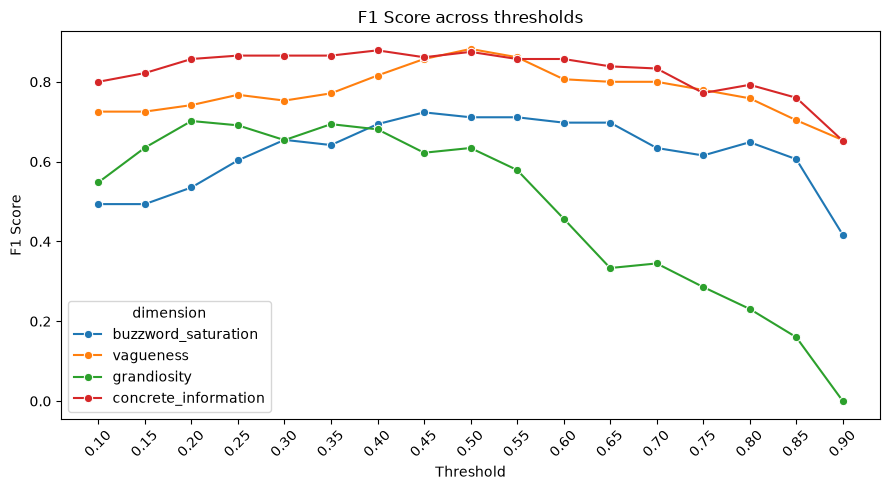

In [22]:
thresholds = np.arange(10, 91, 5) / 100
threshold_rows = []

for dimension, samples in prepared_by_dimension.items():
    for threshold in thresholds:
        binary_predictions = (samples["prediction"] >= threshold).astype(int)
        threshold_rows.append({
            "dimension": dimension,
            "threshold": threshold,
            "f1": f1_score(samples["label"], binary_predictions, zero_division=0),
            "precision": precision_score(samples["label"], binary_predictions, zero_division=0),
            "recall": recall_score(samples["label"], binary_predictions, zero_division=0),
        })

threshold_results = pd.DataFrame(threshold_rows)
best_f1_summary = (
    threshold_results.loc[
        threshold_results.groupby("dimension", sort=False)["f1"].idxmax(),
        ["dimension", "threshold", "f1", "precision", "recall"],
    ]
    .rename(columns={"threshold": "best_threshold"})
    .reset_index(drop=True)
)
display(best_f1_summary)

plt.figure(figsize=(9, 5))
sns.lineplot(data=threshold_results, x="threshold", y="f1", hue="dimension", marker="o")
plt.xticks(thresholds, rotation=45)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score across thresholds")
plt.tight_layout()
plt.show()

#### Score Distributions

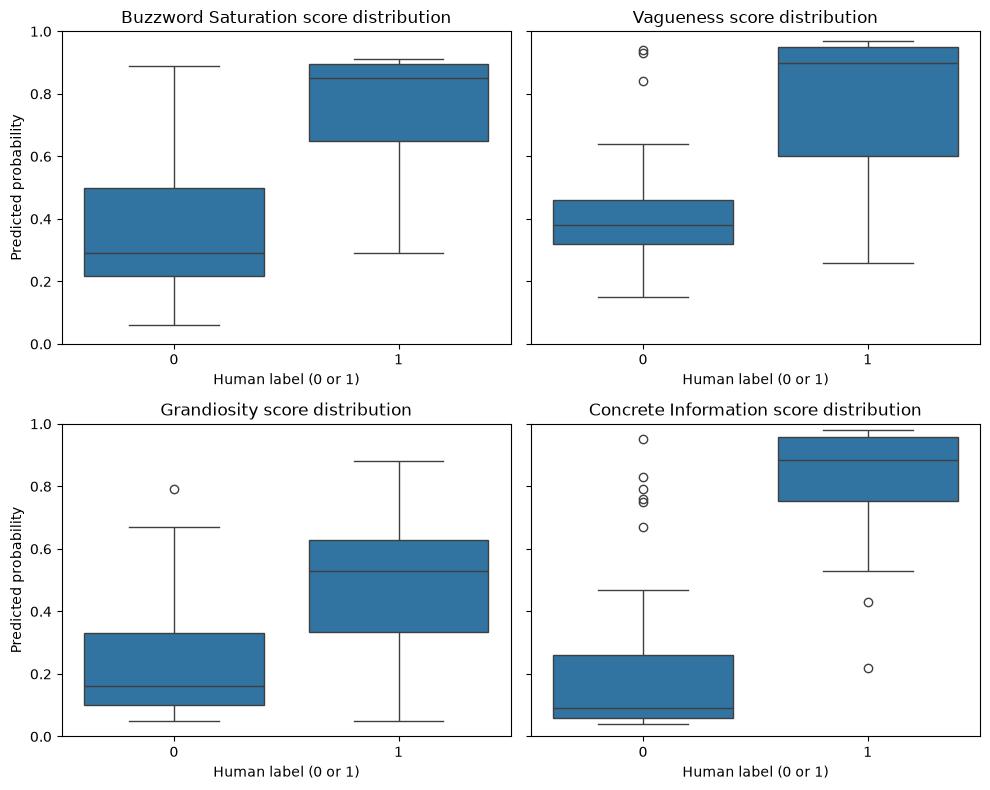

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)

for (dimension, samples), ax in zip(prepared_by_dimension.items(), axes.flat):
    plot_data = samples.loc[samples["label"].isin([0, 1])].copy()
    plot_data["human_label"] = plot_data["label"].astype(str)

    sns.boxplot(data=plot_data, x="human_label", y="prediction", order=["0", "1"], ax=ax)
    ax.set_title(f"{dimension.replace('_', ' ').title()} score distribution")
    ax.set_xlabel("Human label (0 or 1)")
    ax.set_ylabel("Predicted probability")
    ax.set_ylim(0, 1)

fig.tight_layout()
plt.show()

#### False Positive and False Negative Analysis

`error_confidence` is the probability assigned to the incorrect predicted class: `p` for false positives and `1 - p` for false negatives.

In [26]:
exploratory_thresholds = (
    threshold_results.loc[
        threshold_results.groupby("dimension", sort=False)["f1"].idxmax()
    ]
    .set_index("dimension")["threshold"]
)
error_columns = [
    "id", "text", "dimension", "human_label", "predicted_probability",
    "predicted_label", "error_type", "error_confidence",
]
error_frames = []

for dimension, prediction_col in dimension_columns.items():
    samples = evaluation_df.loc[
        evaluation_df[dimension] != "?", ["id", "text", dimension, prediction_col]
    ].copy()
    samples[dimension] = samples[dimension].astype(int)
    samples["predicted_label"] = (
        samples[prediction_col] >= exploratory_thresholds[dimension]
    ).astype(int)
    samples = samples.loc[samples[dimension] != samples["predicted_label"]].copy()
    samples["dimension"] = dimension
    samples["error_type"] = np.where(
        samples[dimension] == 0, "false_positive", "false_negative"
    )
    samples["error_confidence"] = np.where(
        samples["predicted_label"] == 1,
        samples[prediction_col],
        1 - samples[prediction_col],
    )
    samples = samples.rename(columns={
        dimension: "human_label", prediction_col: "predicted_probability"
    })
    error_frames.append(samples[error_columns])

error_analysis_df = (
    pd.concat(error_frames, ignore_index=True)
    .sort_values("error_confidence", ascending=False)
    .reset_index(drop=True)
)

for dimension in dimension_columns:
    for error_type in ("false_positive", "false_negative"):
        print(f"{dimension}: {error_type.replace('_', ' ')}")
        display(error_analysis_df.loc[
            (error_analysis_df["dimension"] == dimension)
            & (error_analysis_df["error_type"] == error_type)
        ].head(5))

buzzword_saturation: false positive


,id,text,dimension,human_label,predicted_probability,predicted_label,error_type,error_confidence
6,CBS023,"The financial landscape continues to evolve, a...",buzzword_saturation,0,0.89,1,false_positive,0.89
7,CBS035,"Together, we can accelerate a more sustainable...",buzzword_saturation,0,0.87,1,false_positive,0.87
8,CBS050,Great leadership starts with people. We are cr...,buzzword_saturation,0,0.86,1,false_positive,0.86
9,CBS103,We believe in a more connected financial futur...,buzzword_saturation,0,0.86,1,false_positive,0.86
10,CBS009,"Across the supply chain, connection matters mo...",buzzword_saturation,0,0.84,1,false_positive,0.84


buzzword_saturation: false negative


,id,text,dimension,human_label,predicted_probability,predicted_label,error_type,error_confidence
22,CBS166,One of my favorite new capabilities in Zoom AI...,buzzword_saturation,1,0.29,0,false_negative,0.71
24,CBS001,We shipped version 2.3 of our retrieval servic...,buzzword_saturation,1,0.32,0,false_negative,0.68


vagueness: false positive


...

,id,text,dimension,human_label,predicted_probability,predicted_label,error_type,error_confidence
1,CBS120,Organizations often describe change as a desti...,grandiosity,1,0.05,0,false_negative,0.95
4,CBS100,We have been reflecting on what it means to le...,grandiosity,1,0.07,0,false_negative,0.93
5,CBS014,"Leadership is a practice of listening, learnin...",grandiosity,1,0.09,0,false_negative,0.91


concrete_information: false positive


,id,text,dimension,human_label,predicted_probability,predicted_label,error_type,error_confidence
0,CBS168,Claude Opus 4 is our most powerful model yet a...,concrete_information,0,0.95,1,false_positive,0.95
12,CBS111,The startup announced a strategic intelligence...,concrete_information,0,0.83,1,false_positive,0.83
15,CBS074,A business plan should update when the busines...,concrete_information,0,0.79,1,false_positive,0.79
19,CBS173,Agentforce digital labor platform includes new...,concrete_information,0,0.76,1,false_positive,0.76
20,CBS013,We are testing a faster way to review repeat l...,concrete_information,0,0.75,1,false_positive,0.75


concrete_information: false negative


,id,text,dimension,human_label,predicted_probability,predicted_label,error_type,error_confidence
16,CBS164,Introducing Atlassian Williams Racing. We're o...,concrete_information,1,0.22,0,false_negative,0.78


## Bullshitscore Definition